# Comprehensive Medical AI Notebook

This notebook fuses four independent medical AI/ML projects into a single, organized pipeline:

1. **Part 1 – ICU Prediction** (`dl-of-interpolation-nn-for-icu-prediction`): Time-series interpolation + ClinicalBERT + LSTM for ICU mortality / LOS prediction using MIMIC-III.
2. **Part 2 – Heart Disease (UCI)** (`heart-disease-uci`): Classical ML (SVM) on the UCI Heart Disease dataset.
3. **Part 3 – Skolyn Chest X-Ray Diagnostics** (`skolyn-os`): Multi-label DenseNet121 chest X-ray classifier with Grad-CAM XAI reporting.
4. **Part 4 – PTB-XL ECG Dataset Wrangling** (`ptb-xl-dataset-wrangling`): EDA and wrangling of the PTB-XL 12-lead ECG dataset.

---


---
# Part 1 – ICU Prediction via Interpolation + ClinicalBERT + LSTM

**Goal:** Predict ICU patient mortality and length-of-stay (LOS) using interpolated time-series vitals fused with BERT embeddings from clinical notes.


## 1.1 Preprocessing the Time Series Data

C:\Users\hp\AppData\Local\Temp\ipykernel_16876\1107467445.py:9: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  time_index = pd.date_range(start='2024-09-01', periods=5, freq='H')


Original time series data with missing values:
                     heart_rate  blood_pressure
timestamp                                      
2024-09-01 00:00:00   79.967142      116.487946
2024-09-01 01:00:00   73.617357      143.688192
2024-09-01 02:00:00   81.476885      131.511521
2024-09-01 03:00:00   90.230299      112.957884
2024-09-01 04:00:00   72.658466      128.138401


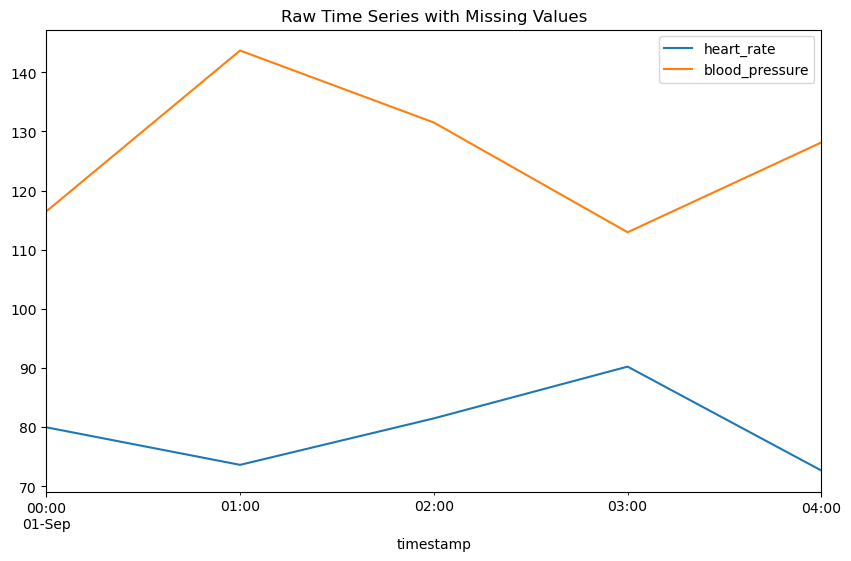

C:\Users\hp\AppData\Local\Temp\ipykernel_16876\1107467445.py:37: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_resampled = df.resample('1H').mean()



Interpolated time series data:
                     heart_rate  blood_pressure
timestamp                                      
2024-09-01 00:00:00   79.967142      116.487946
2024-09-01 01:00:00   73.617357      143.688192
2024-09-01 02:00:00   81.476885      131.511521
2024-09-01 03:00:00   90.230299      112.957884
2024-09-01 04:00:00   72.658466      128.138401


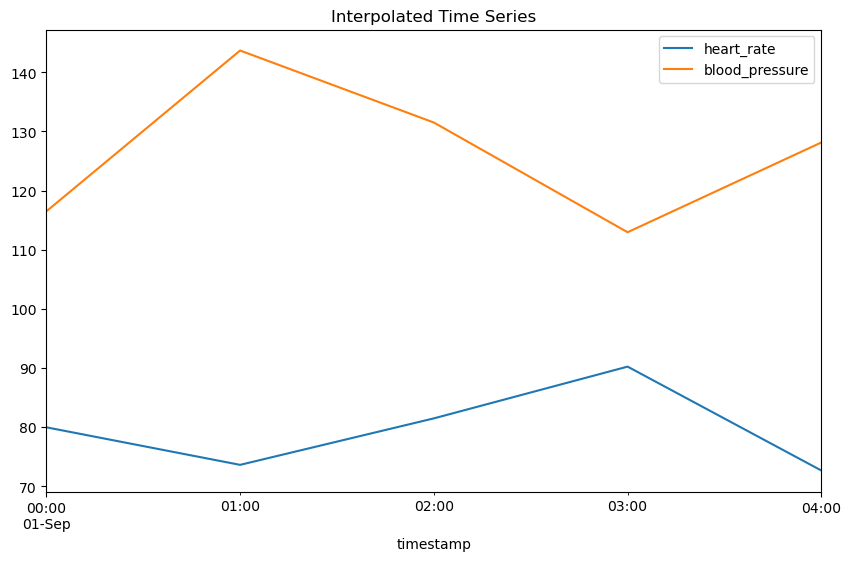

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Simulate time series data for heart rate (HR) and blood pressure (BP)
np.random.seed(42)

# Generate time index for 48 hours with hourly data
time_index = pd.date_range(start='2024-09-01', periods=5, freq='H')

# Simulate random heart rate and blood pressure data with some missing values
heart_rate = np.random.normal(loc=75, scale=10, size=len(time_index))
blood_pressure = np.random.normal(loc=120, scale=15, size=len(time_index))

# Introduce some missing values (NaN)
heart_rate[10:15] = np.nan
blood_pressure[30:35] = np.nan

# Create a DataFrame
df = pd.DataFrame({
    'timestamp': time_index,
    'heart_rate': heart_rate,
    'blood_pressure': blood_pressure
})

# Set the timestamp as index
df.set_index('timestamp', inplace=True)

print("Original time series data with missing values:")
print(df.head(10))

# Plot the time series with missing values
df.plot(y=['heart_rate', 'blood_pressure'], figsize=(10, 6), title="Raw Time Series with Missing Values")
plt.show()

# Resample the data to hourly intervals
df_resampled = df.resample('1H').mean()

# Apply linear interpolation to fill missing values
df_interpolated = df_resampled.interpolate(method='linear')

print("\nInterpolated time series data:")
print(df_interpolated.head(10))

# Plot the interpolated time series
df_interpolated.plot(y=['heart_rate', 'blood_pressure'], figsize=(10, 6), title="Interpolated Time Series")
plt.show()


In [2]:
# Add a patient ID column to merge with clinical note embeddings later
df_time_series = df_interpolated.copy()
df_time_series['patient_id'] = range(len(df_time_series))
df_time_series.head()


,heart_rate,blood_pressure,patient_id
timestamp,,,
2024-09-01 00:00:00,79.967142,116.487946,0
2024-09-01 01:00:00,73.617357,143.688192,1
2024-09-01 02:00:00,81.476885,131.511521,2
2024-09-01 03:00:00,90.230299,112.957884,3
2024-09-01 04:00:00,72.658466,128.138401,4


In [3]:
df_time_series.info()


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5 entries, 2024-09-01 00:00:00 to 2024-09-01 04:00:00
Freq: h
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   heart_rate      5 non-null      float64
 1   blood_pressure  5 non-null      float64
 2   patient_id      5 non-null      int64  
dtypes: float64(2), int64(1)
memory usage: 160.0 bytes


## 1.2 Applying ClinicalBERT on Clinical Notes

In [1]:
from transformers import BertTokenizer, BertModel
from torch.utils.data import DataLoader, Dataset
import torch

# Load pre-trained ClinicalBERT model
tokenizer = BertTokenizer.from_pretrained('emilyalsentzer/Bio_ClinicalBERT')
model_bert = BertModel.from_pretrained('emilyalsentzer/Bio_ClinicalBERT')


ModuleNotFoundError: No module named 'transformers'

In [3]:
device_bert = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_bert.to(device_bert)


NameError: name 'torch' is not defined

In [2]:
notes_list = [
    "Patient admitted to ICU for septic shock. Treated with broad-spectrum antibiotics and vasopressors. BP stabilized after 12 hours.",
    "Patient presented with chest pain. ECG showed ST-elevation, troponin levels elevated. Diagnosis: STEMI. Emergent PCI performed.",
    "Patient admitted after motor vehicle accident with multiple fractures. Surgical fixation of femur completed.",
    "Patient transferred from the emergency room with acute respiratory distress. Intubated and started on mechanical ventilation.",
    "Patient diagnosed with community-acquired pneumonia. Started on IV antibiotics. Oxygen saturation improving.",
]

mortality_labels = [1, 0, 0, 1, 0]


In [6]:
# Tokenizing clinical notes
inputs = tokenizer(notes_list, padding=True, truncation=True, return_tensors="pt").to(device_bert)
labels = torch.tensor(mortality_labels).to(device_bert)

with torch.no_grad():
    outputs = model_bert(**inputs)

# Extract [CLS]-averaged embeddings
embeddings = outputs.last_hidden_state.mean(dim=1)
embeddings_clinical_notes = embeddings.cpu()
print("Clinical note embeddings shape:", embeddings_clinical_notes.shape)


NameError: name 'tokenizer' is not defined

## 1.3 Feature Engineering: Normalize Time-Series Data

In [7]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df_time_series)
print("Scaled data shape:", scaled_data.shape)


Scaled data shape: (5, 3)


## 1.4 LSTM Model Definition

In [8]:
import torch.nn as nn

# Reshape for LSTM: (num_samples, sequence_length, num_features)
time_series_data = scaled_data.reshape(1, scaled_data.shape[0], scaled_data.shape[1])
time_series_tensor = torch.tensor(time_series_data, dtype=torch.float32)
print("Time series tensor shape:", time_series_tensor.shape)

class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        h0 = torch.zeros(num_layers, x.size(0), hidden_size).to(x.device)
        c0 = torch.zeros(num_layers, x.size(0), hidden_size).to(x.device)
        out, _ = self.lstm(x, (h0, c0))
        out = out[:, -1, :]  # Last time step
        out = self.fc(out)
        return out

# Parameters
input_size = 3
hidden_size = 64
num_layers = 2
output_size = 32

lstm_model = LSTMModel(input_size, hidden_size, num_layers, output_size)
device_lstm = torch.device("cuda" if torch.cuda.is_available() else "cpu")
lstm_model.to(device_lstm)


NameError: name 'torch' is not defined

## 1.5 Fuse LSTM + ClinicalBERT Embeddings → Final Prediction

In [ ]:
# Process time-series through LSTM
time_series_tensor = time_series_tensor.to(device_lstm)
with torch.no_grad():
    time_series_embeddings = lstm_model(time_series_tensor)

# Expand LSTM embeddings to match batch size of clinical notes (5 samples)
embeddings_clinical_notes = embeddings_clinical_notes.to(device_lstm)
time_series_embeddings_expanded = time_series_embeddings.expand(5, -1).to(device_lstm)

# Concatenate LSTM + BERT embeddings
combined_embeddings = torch.cat((time_series_embeddings_expanded, embeddings_clinical_notes), dim=1)
print(f"Combined embeddings shape: {combined_embeddings.shape}")  # Expected: (5, 800)

# Simple MLP prediction head
mlp = nn.Linear(800, 1, bias=False).to(device_lstm)
logits = mlp(combined_embeddings).squeeze(dim=-1)
probs = torch.sigmoid(logits)
print("Mortality probabilities:", probs)


---
# Part 2 – Heart Disease Classification (UCI Dataset)

**Goal:** Train a Support Vector Machine (SVM) on the UCI Heart Disease dataset to classify patients as having heart disease or not.


## 2.1 Load and Explore Data

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.chdir('/kaggle/input/heart-diseaseuci')
heart_disease_data = pd.read_csv('heart.csv')

print(heart_disease_data.head(10))
print(heart_disease_data.describe())
print(heart_disease_data.info())
print("\nTarget value counts:")
print(heart_disease_data['target'].value_counts())


FileNotFoundError: [WinError 3] The system cannot find the path specified: '/kaggle/input/heart-diseaseuci'

## 2.2 Feature Engineering and Encoding

In [10]:
# Separate features and target
X = heart_disease_data.loc[:, heart_disease_data.columns != 'target']
y = heart_disease_data.loc[:, "target"]

# One-hot encode categorical columns
X_encoded = pd.get_dummies(
    heart_disease_data,
    columns=['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
)
X_encoded.head()


NameError: name 'heart_disease_data' is not defined

## 2.3 Train/Test Split and Scaling

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=1
)

sc_X = StandardScaler()
X_train = sc_X.fit_transform(X_train)
X_test = sc_X.transform(X_test)


NameError: name 'X_encoded' is not defined

## 2.4 SVM Model Training and Evaluation

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, accuracy_score

svc = SVC(kernel='linear', random_state=0)
svc.fit(X_train, y_train)

y_pred_svc = svc.predict(X_test)

# Results
y_pred_svc_df = pd.DataFrame({'Expected': y_test, 'Predicted': y_pred_svc})
print(y_pred_svc_df.head(10))

svc_cm = confusion_matrix(y_test, y_pred_svc)
svc_acc = accuracy_score(y_test, y_pred_svc)
print("\nConfusion Matrix:")
print(svc_cm)
print(f"\nSVM Accuracy: {svc_acc:.4f}")


---
# Part 3 – Skolyn Chest X-Ray Diagnostic Module

**Goal:** Multi-label DenseNet121 classifier for 15 thoracic pathologies (NIH ChestX-ray14 + CheXpert + Pneumonia datasets), with Grad-CAM explainability for each detected finding.

**Strategy:**
1. **Data Fusion** across NIH, CheXpert, and Pneumonia datasets under a unified `MASTER_FINDINGS` schema.
2. **Multi-Label Classification** — sigmoid outputs per pathology.
3. **Hierarchical Analysis** — subtype (Bacterial/Viral) and severity (simulated).
4. **Grad-CAM XAI** — per-pathology heatmaps.


## 3.1 Imports and Configuration

In [ ]:
import numpy as np
import pandas as pd
import os
import random
import gc
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.models import load_model
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')

print("TensorFlow Version:", tf.__version__)
print("All libraries imported successfully.")


## 3.2 Data Acquisition and Unification

In [ ]:
MASTER_FINDINGS = [
    'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion',
    'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'Nodule',
    'Pleural_Thickening', 'Pneumonia', 'Pneumothorax', 'No Finding'
]

NIH_DATA_PATH      = '/kaggle/input/data'
CHEXPERT_DATA_PATH = '/kaggle/input/chexpert'
PNEUMONIA_DATA_PATH = '/kaggle/input/chest-xray-pneumonia/chest_xray/'

print(f"Master label schema created with {len(MASTER_FINDINGS)} findings.")


In [ ]:
# --- Step 1: Process the NIH Dataset ---
print("Processing NIH ChestX-ray14 dataset...")
nih_df = pd.read_csv(os.path.join(NIH_DATA_PATH, 'Data_Entry_2017.csv'))
nih_df.rename(columns={'Image Index': 'Image_Index', 'Finding Labels': 'Finding_Labels'}, inplace=True)
nih_df['filepath'] = nih_df['Image_Index'].apply(
    lambda x: os.path.join(NIH_DATA_PATH, 'images', x)
)
for finding in MASTER_FINDINGS:
    if finding == 'Pneumonia':
        nih_df[finding] = nih_df['Finding_Labels'].apply(
            lambda x: 1 if 'Infiltration' in x or 'Pneumonia' in x else 0
        )
    else:
        nih_df[finding] = nih_df['Finding_Labels'].apply(lambda x: 1 if finding in x else 0)

print(f"NIH dataset processed. Shape: {nih_df.shape}")
nih_df[['filepath'] + MASTER_FINDINGS].head()


In [ ]:
# --- Step 2: Process the CheXpert Dataset ---
print("\nProcessing CheXpert dataset...")
chexpert_df = pd.read_csv(os.path.join(CHEXPERT_DATA_PATH, 'valid.csv'))
chexpert_df['filepath'] = chexpert_df['Path'].apply(
    lambda x: os.path.join(CHEXPERT_DATA_PATH, '/'.join(x.split('/')[1:]))
)
chexpert_df.rename(columns={'Pleural Effusion': 'Effusion'}, inplace=True)
chexpert_df = chexpert_df.fillna(0).replace(-1, 1)
for finding in MASTER_FINDINGS:
    if finding not in chexpert_df.columns:
        chexpert_df[finding] = 0

print(f"CheXpert dataset processed. Shape: {chexpert_df.shape}")
chexpert_df[['filepath'] + MASTER_FINDINGS].head()


In [ ]:
# --- Step 3: Process the Pneumonia Dataset and simulate advanced labels ---
print("\nProcessing Pneumonia dataset and simulating advanced labels...")
pneumonia_filepaths = []
pneumonia_labels_onehot = []
pneumonia_subtypes = []
pneumonia_severities_simulated = []

for split in ['train', 'test', 'val']:
    base_path = os.path.join(PNEUMONIA_DATA_PATH, split)
    for folder in ['NORMAL', 'PNEUMONIA']:
        folder_path = os.path.join(base_path, folder)
        for filename in os.listdir(folder_path):
            filepath = os.path.join(folder_path, filename)
            pneumonia_filepaths.append(filepath)
            labels = {f: 0 for f in MASTER_FINDINGS}
            subtype = severity = 'N/A'
            if folder == 'NORMAL':
                labels['No Finding'] = 1
            else:
                labels['Pneumonia'] = 1
                if 'bacteria' in filename:
                    subtype = 'Bacterial'
                    severity = random.choice(['Moderate', 'Severe'])
                elif 'virus' in filename:
                    subtype = 'Viral'
                    severity = random.choice(['Mild', 'Moderate'])
            pneumonia_labels_onehot.append(labels)
            pneumonia_subtypes.append(subtype)
            pneumonia_severities_simulated.append(severity)

pneumonia_df = pd.DataFrame(pneumonia_labels_onehot)
pneumonia_df['filepath'] = pneumonia_filepaths
pneumonia_df['Subtype'] = pneumonia_subtypes
pneumonia_df['Severity_Simulated'] = pneumonia_severities_simulated
print(f"Pneumonia dataset processed. Shape: {pneumonia_df.shape}")
pneumonia_df.sample(5)


In [ ]:
# --- Step 4: Fuse all datasets into a master DataFrame ---
print("Fusing all datasets...")
nih_subset       = nih_df[['filepath'] + MASTER_FINDINGS]
chexpert_subset  = chexpert_df[['filepath'] + MASTER_FINDINGS]
pneumonia_subset = pneumonia_df[['filepath'] + MASTER_FINDINGS + ['Subtype', 'Severity_Simulated']]

master_df = pd.concat([nih_subset, chexpert_subset, pneumonia_subset], ignore_index=True)
master_df = master_df.fillna('N/A').drop_duplicates(subset=['filepath'])

del nih_df, chexpert_df, pneumonia_df, nih_subset, chexpert_subset
gc.collect()

print(f"Data fusion complete. Total unique images: {master_df.shape[0]}")
findings_counts = master_df[MASTER_FINDINGS].sum().sort_values(ascending=False)
plt.figure(figsize=(15, 8))
sns.barplot(x=findings_counts.values, y=findings_counts.index, palette='viridis')
plt.title('Distribution of Pathologies in the Fused Master Dataset')
plt.xlabel('Number of Cases')
plt.show()


In [ ]:
# --- Step 5: Split data and create Keras generators ---
sample_df = master_df.sample(frac=0.2, random_state=42)
train_df, valid_df = train_test_split(sample_df, test_size=0.15, random_state=42)
print(f"Training set size: {len(train_df)}")
print(f"Validation set size: {len(valid_df)}")

IMG_SIZE   = (256, 256)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255., horizontal_flip=True,
    rotation_range=10, width_shift_range=0.1,
    height_shift_range=0.1, shear_range=0.1, zoom_range=0.1
)
valid_datagen = ImageDataGenerator(rescale=1./255.)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df, x_col='filepath', y_col=MASTER_FINDINGS,
    target_size=IMG_SIZE, class_mode='raw', batch_size=BATCH_SIZE, shuffle=True
)
valid_generator = valid_datagen.flow_from_dataframe(
    dataframe=valid_df, x_col='filepath', y_col=MASTER_FINDINGS,
    target_size=IMG_SIZE, class_mode='raw', batch_size=BATCH_SIZE, shuffle=False
)


## 3.3 Building the DenseNet121 Diagnostic Model

In [ ]:
# --- Step 6: Define and Compile the Model ---
base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
base_model.trainable = True

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
predictions = Dense(len(MASTER_FINDINGS), activation='sigmoid', name='predictions')(x)

chest_model = Model(inputs=base_model.input, outputs=predictions)
chest_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=[tf.keras.metrics.AUC(multi_label=True, name='auc')]
)
chest_model.summary()


In [ ]:
# --- Step 7: Train the Model ---
checkpoint_path = 'skolyn_comprehensive_chest_model_v1.h5'
callbacks = [
    ModelCheckpoint(checkpoint_path, monitor='val_auc', mode='max', verbose=1, save_best_only=True),
    EarlyStopping(monitor='val_auc', mode='max', patience=5, verbose=1),
    ReduceLROnPlateau(monitor='val_auc', mode='max', factor=0.5, patience=2, verbose=1)
]
EPOCHS = 8

history = chest_model.fit(
    train_generator,
    steps_per_epoch=len(train_df) // BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=valid_generator,
    validation_steps=len(valid_df) // BATCH_SIZE,
    callbacks=callbacks
)


## 3.4 Explainable AI (XAI) Engine – Grad-CAM

In [ ]:
# --- Step 8: XAI Helper Functions ---

def find_correct_image_path(relative_path):
    possible_base_paths = [
        '/kaggle/input/data',
        '/kaggle/input/chexpert',
        '/kaggle/input/chexpert/train/',
        '/kaggle/input/chexpert/val/'
    ]
    filename = os.path.basename(relative_path)
    if os.path.exists(relative_path):
        return relative_path
    for base_path in possible_base_paths:
        potential_path = os.path.join(base_path, filename)
        if os.path.exists(potential_path):
            return potential_path
    for base_path in possible_base_paths:
        for root, dirs, files in os.walk(base_path):
            if filename in files:
                return os.path.join(root, filename)
    return None

def preprocess_single_image(img_path, target_size=(256, 256)):
    correct_path = find_correct_image_path(img_path)
    if correct_path is None:
        print(f"ERROR: Image not found: {img_path}")
        return None, None
    img = cv2.imread(correct_path)
    if img is None:
        print(f"ERROR: OpenCV could not read: {correct_path}")
        return None, None
    img = cv2.resize(img, target_size)
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0
    return img_array, img

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index):
    grad_model = Model(model.inputs, [model.get_layer(last_conv_layer_name).output, model.output])
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        class_channel = preds[:, pred_index]
    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = last_conv_layer_output[0] @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

def superimpose_gradcam(original_img, heatmap, alpha=0.5):
    heatmap = cv2.resize(heatmap, (original_img.shape[1], original_img.shape[0]))
    heatmap = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
    superimposed_img = np.clip(heatmap * alpha + original_img, 0, 255).astype(np.uint8)
    return superimposed_img

print("XAI helper functions defined.")


In [ ]:
# --- Step 9: Master Reporting Function ---

def generate_skolyn_comprehensive_report(image_path, model, master_df_ref, threshold=0.3):
    img_array, original_img = preprocess_single_image(image_path, target_size=IMG_SIZE)
    if img_array is None:
        return
    predictions = model.predict(img_array)[0]
    detected_findings = {
        MASTER_FINDINGS[i]: pred
        for i, pred in enumerate(predictions)
        if pred > threshold and MASTER_FINDINGS[i] != 'No Finding'
    }

    print("=" * 60)
    print("      SKOLYN COMPREHENSIVE DIAGNOSTIC REPORT")
    print("=" * 60)
    print(f"Image File: {os.path.basename(image_path)}\n")
    print(f"--- PRIMARY FINDINGS (Prob > {threshold*100:.0f}%) ---")

    if not detected_findings:
        no_finding_prob = predictions[MASTER_FINDINGS.index('No Finding')]
        print(f"  - No significant pathological findings detected.")
        print(f"    (Confidence for 'No Finding': {no_finding_prob*100:.2f}%)")
    else:
        for finding, confidence in detected_findings.items():
            print(f"  - {finding.replace('_', ' ')}: Detected ({confidence*100:.2f}%)")
            img_info = master_df_ref[master_df_ref['filepath'] == image_path]
            if not img_info.empty:
                subtype  = img_info['Subtype'].values[0]
                severity = img_info['Severity_Simulated'].values[0]
                if subtype  != 'N/A': print(f"    - Subtype: '{subtype}'")
                if severity != 'N/A': print(f"    - Severity (SIMULATED): '{severity}'")

    print("\n--- VISUAL EXPLANATION (XAI Heatmaps) ---")
    last_conv_layer_name = 'conv5_block16_concat'
    num_plots = len(detected_findings) if detected_findings else 1
    fig, axes = plt.subplots(1, num_plots + 1, figsize=(6 * (num_plots + 1), 6))
    if not isinstance(axes, np.ndarray):
        axes = [axes]
    axes[0].imshow(cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB))
    axes[0].set_title("Original X-Ray")
    axes[0].axis('off')
    if not detected_findings:
        axes[1].imshow(cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB))
        axes[1].set_title("Result: Normal")
        axes[1].axis('off')
    else:
        for plot_idx, finding in enumerate(detected_findings.keys(), start=1):
            finding_index = MASTER_FINDINGS.index(finding)
            heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name, finding_index)
            superimposed_img = superimpose_gradcam(original_img, heatmap)
            axes[plot_idx].imshow(cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB))
            axes[plot_idx].set_title(f"XAI: {finding.replace('_', ' ')}")
            axes[plot_idx].axis('off')
    plt.tight_layout()
    plt.show()


In [ ]:
# --- Step 10: Load best model and run demonstrations ---
final_model = load_model(checkpoint_path, compile=False)

def get_valid_sample_path(df_subset):
    for path in df_subset.filepath.values:
        if find_correct_image_path(path) is not None:
            return path
    return None

# Demo 1: Pneumonia
print("\n--- DEMO 1: PNEUMONIA CASE ---")
pneumonia_subset = valid_df[valid_df['Subtype'] != 'N/A']
pneumonia_sample_path = get_valid_sample_path(pneumonia_subset)
if pneumonia_sample_path:
    generate_skolyn_comprehensive_report(pneumonia_sample_path, final_model, master_df)
else:
    print("No valid pneumonia sample found.")

# Demo 2: Normal
print("\n--- DEMO 2: NORMAL CASE ---")
normal_subset = valid_df[valid_df['No Finding'] == 1]
normal_sample_path = get_valid_sample_path(normal_subset)
if normal_sample_path:
    generate_skolyn_comprehensive_report(normal_sample_path, final_model, master_df)
else:
    print("No valid normal sample found.")

# Demo 3: Multi-finding
print("\n--- DEMO 3: MULTI-FINDING CASE ---")
multi_finding_subset = valid_df[valid_df[MASTER_FINDINGS].sum(axis=1) > 2]
multi_finding_path = get_valid_sample_path(multi_finding_subset)
if multi_finding_path:
    generate_skolyn_comprehensive_report(multi_finding_path, final_model, master_df)
else:
    print("No valid multi-finding sample found.")


---
# Part 4 – PTB-XL ECG Dataset Wrangling & EDA

**Goal:** Load and wrangle the PTB-XL 12-lead ECG dataset, annotate records with diagnostic superclass and subclass labels, and perform exploratory data analysis on demographics and label distributions.


## 4.1 Imports

In [ ]:
import pandas as pd
import numpy as np
import wfdb
import ast
from tqdm import tqdm
import warnings; warnings.filterwarnings('ignore')
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline


## 4.2 Load Raw Data

In [ ]:
def load_raw_data(df, sampling_rate, path):
    if sampling_rate == 100:
        data = [wfdb.rdsamp(path + f) for f in tqdm(df.filename_lr)]
    else:
        data = [wfdb.rdsamp(path + f) for f in tqdm(df.filename_hr)]
    data = np.array([signal for signal, meta in data])
    return data

path = '../input/ptb-xl-dataset/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1/'
sampling_rate = 100

# Load annotation data
Y = pd.read_csv(path + 'ptbxl_database.csv', index_col='ecg_id')
Y.scp_codes = Y.scp_codes.apply(lambda x: ast.literal_eval(x))

# Load raw signal data
X = load_raw_data(Y, sampling_rate, path)
print('Data shape:', X.shape)
Y[['scp_codes']].head()


## 4.3 Diagnostic Label Aggregation

In [ ]:
# Load SCP statements for diagnostic aggregation
agg_df = pd.read_csv(path + 'scp_statements.csv', index_col=0)
agg_df = agg_df[agg_df.diagnostic == 1]
print(agg_df.shape)
agg_df.head()


In [ ]:
def aggregate_superclass_diagnostic(y_dic):
    tmp = []
    for key in y_dic.keys():
        if key in agg_df.index:
            tmp.append(agg_df.loc[key].diagnostic_class)
    return list(set(tmp))

def aggregate_subclass_diagnostic(y_dic):
    tmp = []
    for key in y_dic.keys():
        if key in agg_df.index:
            tmp.append(agg_df.loc[key].diagnostic_subclass)
    ret = list(set(tmp))
    ret = ['sub_' + r for r in ret]
    return ret

Y['diagnostic_superclass'] = Y.scp_codes.apply(aggregate_superclass_diagnostic)
Y['diagnostic_superclass_len'] = Y['diagnostic_superclass'].apply(len)
Y['diagnostic_subclass'] = Y.scp_codes.apply(aggregate_subclass_diagnostic)
Y['diagnostic_subclass_len'] = Y['diagnostic_subclass'].apply(len)
print("Columns:", Y.columns.tolist())


## 4.4 Superclass Distribution

In [ ]:
vc = Y['diagnostic_superclass_len'].value_counts()
sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=vc.values / vc.values.sum() * 100., y=vc.index,
            palette="muted", orient='h', ax=ax)
ax.set_title("Diagnostic Superclass Length Distribution", fontsize=20)
ax.set_xlabel("Percentage over all samples")
ax.set_ylabel("diagnostic_superclass_len")
for rect in ax.patches:
    ax.text(rect.get_width(), rect.get_y() + rect.get_height() / 2,
            "%.1f%%" % rect.get_width(), weight='bold')
plt.tight_layout()
plt.show()


**Superclass Meanings:**
- **NORM**: Normal ECG
- **MI**: Myocardial Infarction
- **STTC**: ST/T Change
- **CD**: Conduction Disturbance
- **HYP**: Hypertrophy


## 4.5 Reformat Data for EDA

In [ ]:
all_superclass = pd.Series(np.concatenate(Y['diagnostic_superclass'].values))
all_subclass   = pd.Series(np.concatenate(Y['diagnostic_subclass'].values))
superclass_cols = all_superclass.unique()
subclass_cols   = all_subclass.unique()
update_cols = np.concatenate([superclass_cols, subclass_cols])
meta_cols   = ['age', 'sex', 'height', 'weight', 'nurse', 'site', 'device']

class ClassUpdate:
    def __init__(self, cols):
        self.cols = cols
    def __call__(self, row):
        for sc in row['diagnostic_superclass']:
            row[sc] = 1
        for sc in row['diagnostic_subclass']:
            row[sc] = 1
        return row

def get_data_by_folds(folds, x, y, update_cols, feature_cols):
    assert len(folds) > 0
    filt = np.isin(y.strat_fold.values, folds)
    x_selected = x[filt]
    y_selected = y[filt].copy()
    for sc in update_cols:
        y_selected[sc] = 0
    cls_updt = ClassUpdate(update_cols)
    y_selected = y_selected.apply(cls_updt, axis=1)
    return x_selected, y_selected[list(feature_cols) + list(update_cols) + ['strat_fold']]

x_all, y_all = get_data_by_folds(np.arange(1, 11), X, Y, update_cols, meta_cols)
y_all.head()


## 4.6 Pathology Distribution Plots

In [ ]:
# Superclass distribution
vc = y_all[superclass_cols].sum(axis=0)
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=vc.values / y_all.shape[0] * 100., y=vc.index, palette="muted", orient='h', ax=ax)
ax.set_title("Diagnostic Superclass Distribution", fontsize=20)
ax.set_xlabel("Percentage over all samples")
for rect in ax.patches:
    ax.text(rect.get_width(), rect.get_y() + rect.get_height() / 2,
            "%.1f%%" % rect.get_width(), weight='bold')
plt.tight_layout()
plt.show()


In [ ]:
# Subclass distribution
vc = y_all[subclass_cols].sum(axis=0)
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=vc.values / y_all.shape[0] * 100., y=vc.index, palette="muted", orient='h', ax=ax)
ax.set_title("Diagnostic Subclass Distribution", fontsize=20)
ax.set_xlabel("Percentage over all samples")
for rect in ax.patches:
    ax.text(rect.get_width(), rect.get_y() + rect.get_height() / 2,
            "%.1f%%" % rect.get_width(), weight='bold')
plt.tight_layout()
plt.show()


In [ ]:
# Subclass distribution per superclass
for superclass in superclass_cols:
    vc = y_all.loc[y_all[superclass] == 1][subclass_cols].sum(axis=0)
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.barplot(x=vc.values / y_all.shape[0] * 100., y=vc.index, palette="muted", orient='h', ax=ax)
    ax.set_title(f"{superclass} Subclass Distribution", fontsize=20)
    ax.set_xlabel("Percentage over all samples")
    for rect in ax.patches:
        ax.text(rect.get_width(), rect.get_y() + rect.get_height() / 2,
                "%.1f%%" % rect.get_width(), weight='bold')
    plt.tight_layout()
    plt.show()


## 4.7 Demographic Analysis by Superclass

In [ ]:
# Age distribution
fig, ax = plt.subplots(figsize=(10, 6))
plt.title('Age Distributions by Superclass')
for superclass in superclass_cols:
    data = y_all.loc[y_all[superclass] == 1]['age']
    sns.distplot(data, label=superclass)
plt.legend(loc='upper left')
plt.show()


In [ ]:
# Height distribution
fig, ax = plt.subplots(figsize=(10, 6))
plt.title('Height Distributions by Superclass')
for superclass in superclass_cols:
    data = y_all.loc[y_all[superclass] == 1][['height']]
    sns.distplot(data, label=superclass)
plt.legend(labels=superclass_cols, loc='upper left')
plt.show()


In [ ]:
# Weight distribution
fig, ax = plt.subplots(figsize=(10, 6))
plt.title('Weight Distributions by Superclass')
for superclass in superclass_cols:
    data = y_all.loc[y_all[superclass] == 1][['weight']]
    sns.distplot(data, label=superclass)
plt.legend(labels=superclass_cols, loc='upper left')
plt.show()


In [ ]:
# Superclass by sex
sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_title("Diagnostic Superclass Distribution by Sex", fontsize=20)

all_index, all_count, all_values = [], [], []
for sex in y_all.sex.unique():
    vc = y_all.loc[y_all.sex == sex][superclass_cols].sum(axis=0)
    all_index  += list(vc.index)
    all_count  += list(vc.values / y_all.shape[0] * 100.)
    all_values += [sex] * len(vc)

sex_df = pd.DataFrame({
    'diagnositic superclass': all_index,
    'percentage over all samples': all_count,
    'sex': all_values
})
ax = sns.barplot(data=sex_df, x="percentage over all samples",
                 y="diagnositic superclass", hue="sex", orient='h', ax=ax)
for rect in ax.patches:
    ax.text(rect.get_width(), rect.get_y() + rect.get_height() / 2,
            "%.1f%%" % rect.get_width(), weight='bold')
plt.tight_layout()
plt.show()


---
# Summary

| Part | Task | Key Tech |
|------|------|----------|
| 1 | ICU Mortality / LOS Prediction | Time-series interpolation, ClinicalBERT, LSTM, PyTorch |
| 2 | Heart Disease Classification (UCI) | SVM, scikit-learn |
| 3 | Chest X-Ray Diagnostics (Skolyn) | DenseNet121, multi-label classification, Grad-CAM, TensorFlow/Keras |
| 4 | PTB-XL ECG EDA | WFDB, multi-label ECG annotation, Seaborn EDA |

Each section is self-contained with its own data paths and imports — run them sequentially or independently as needed.
